In [1]:
import pandas as pd
import os
from utils import convert_gpx_to_csv
from Struc_stat_gps import Donnees_gps
from analyse_statistque import Stat

In [2]:
root = "../output/"

#SEPARATION_ALTITUDE = trace_RPi.Altitude.isnull().values.sum()

def gpx_to_csv(paff):
    if not os.path.exists(paff+".csv"):
        convert_gpx_to_csv(paff+".gpx", paff+".csv")

def import_Data(paff):
    sources = ("_RPI", "_Chloe", "_Thomas")
    for src in sources[1:] :
        gpx_to_csv(root+paff+"/GPS_"+paff+src)
    df = [pd.read_csv((root+paff+"/GPS_"+paff+src+".csv")) for src in sources]

    return df[0], df[1], df[2]

#gps_data1 = pd.read_csv(acquisitionGPS_1)
#gps_data2 = pd.read_csv(acquisitionGPS_2)

#trace_RPi = pd.concat([gps_data1, gps_data2])

In [3]:
def nb_NaN(df):
    return df.isnull().values.sum()

def compare_Timestamp(tstmp_RPi, tstmp):
    return tstmp_RPi+"Z" == tstmp



In [4]:
d = Donnees_gps("borne")

/!\ Warning : Des colonnes sont manquantes pour la source Chloe => ['Date_Formatee', 'Latitude', 'Longitude']
/!\ Warning : Des colonnes sont manquantes pour la source Thomas => ['Date_Formatee', 'Latitude', 'Longitude']


In [5]:
d.match_date_sans_NaN

,Date,Thomas_Longitude,Thomas_Latitude,Chloe_Longitude,Chloe_Latitude,RPI_Longitude,RPI_Latitude
4,2025-03-18 17:12:16+00:00,1.068238,49.385783,1.068247,49.385807,1.068256,49.385767
5,2025-03-18 17:12:17+00:00,1.068238,49.385783,1.068248,49.385810,1.068257,49.385768
6,2025-03-18 17:12:18+00:00,1.068238,49.385783,1.068249,49.385809,1.068257,49.385769
7,2025-03-18 17:12:19+00:00,1.068238,49.385783,1.068247,49.385806,1.068256,49.385770
8,2025-03-18 17:12:20+00:00,1.068238,49.385783,1.068247,49.385806,1.068256,49.385771
...,...,...,...,...,...,...,...
90,2025-03-18 17:13:42+00:00,1.068238,49.385783,1.068244,49.385781,1.068269,49.385789
91,2025-03-18 17:13:43+00:00,1.068238,49.385783,1.068244,49.385781,1.068269,49.385789
92,2025-03-18 17:13:44+00:00,1.068238,49.385783,1.068244,49.385781,1.068269,49.385789
93,2025-03-18 17:13:45+00:00,1.068238,49.385783,1.068243,49.385782,1.068269,49.385790


In [6]:
balade = Donnees_gps("leclerc")
balade

/!\ Warning : Des colonnes sont manquantes pour la source Chloe => ['Date_Formatee', 'Latitude', 'Longitude']
/!\ Warning : Des colonnes sont manquantes pour la source Thomas => ['Date_Formatee', 'Latitude', 'Longitude']


In [7]:
from analyse_statistque import Stat

In [8]:
s = Stat(balade.match_date_sans_NaN)


In [9]:
print(f"Test des rangs Chloe vs Thomas : {s.test_des_rangs('Chloe','Thomas')}")
print(f"Test des rangs RPI vs Thomas :   {s.test_des_rangs('RPI','Thomas')}")
print(f"Test des rangs RPI vs Chloe :    {s.test_des_rangs('RPI','Chloe')}")

Test des rangs Chloe vs Thomas : WilcoxonResult(statistic=0.0, pvalue=1.7027557559357892e-113)
Test des rangs RPI vs Thomas :   WilcoxonResult(statistic=0.0, pvalue=1.7027557559357892e-113)
Test des rangs RPI vs Chloe :    WilcoxonResult(statistic=0.0, pvalue=1.7027557559357892e-113)


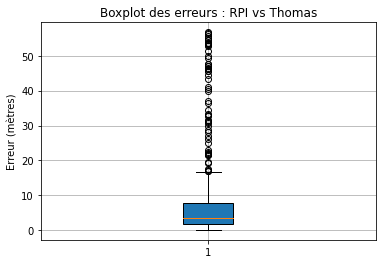

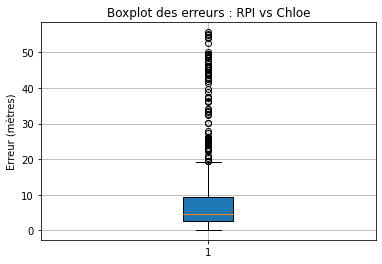

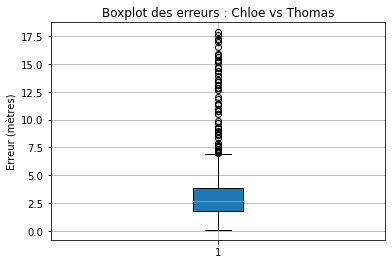

In [10]:
s.boxplot_erreurs("RPI","Thomas")
s.boxplot_erreurs("RPI", "Chloe")
s.boxplot_erreurs("Chloe", "Thomas")

In [11]:
print(f"moyenne des erreurs Chloe vs RPI    = {s.moyenne_erreurs('Chloe', 'RPI')}")
print(f"moyenne des erreurs Thomas vs RPI   = {s.moyenne_erreurs('Thomas', 'RPI')}")
print(f"moyenne des erreurs Chloe vs Thomas = {s.moyenne_erreurs('Chloe', 'Thomas')}")

moyenne des erreurs Chloe vs RPI    = 9.01358976720802
moyenne des erreurs Thomas vs RPI   = 7.5027175262593975
moyenne des erreurs Chloe vs Thomas = 3.4307983783030997


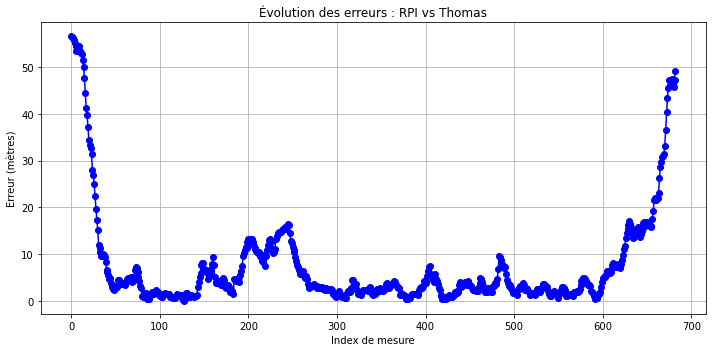

In [12]:
s.courbe_erreurs("RPI", "Thomas")

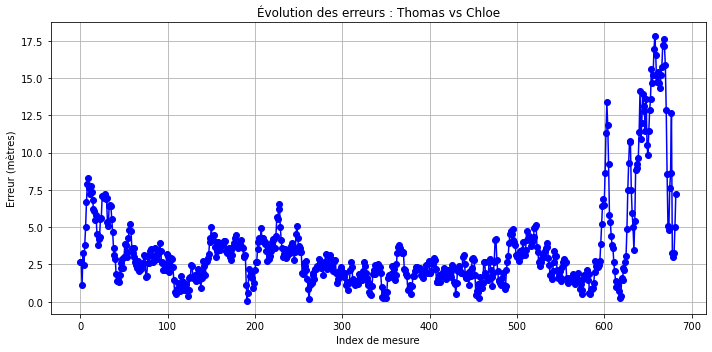

In [13]:
s.courbe_erreurs("Thomas", "Chloe")

In [20]:
balade.match_date_sans_NaN['Thomas_Latitude'][200] - balade.match_date_sans_NaN['Chloe_Latitude'][200]

-1.5500000003498826e-06

In [ ]:
print()